# Maintenance Prédictive des Éoliennes
## Classification multiclasse — Turbine 1

Ce notebook couvre l'analyse exploratoire, le nettoyage des données, la construction d'un pipeline de preprocessing et la comparaison de plusieurs modèles de classification pour prédire les besoins de maintenance (labels 0, 1, 2).

**Métrique cible :** F1-Score macro — toutes les classes comptent également, y compris les pannes rares.

---
### Import des librairies

In [1]:
import warnings
# Suppression du DeprecationWarning interne scipy/sklearn (lbfgs disp/iprint)
warnings.filterwarnings('ignore', message='.*disp.*', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*iprint.*', category=DeprecationWarning)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
from dotenv import load_dotenv
import boto3

---
## Import du dataset

Les données proviennent d'un bucket S3 (accès via variables d'environnement). En développement local, on peut également charger les fichiers directement depuis `data/raw/`.

**Chargement local** — import depuis le dossier `data/raw/` (mode développement)

In [2]:
dataset = pd.read_csv('../data/raw/wind_turbine_maintenance_data.csv')

---
## 1. Analyse Exploratoire des Données (EDA)

On commence par examiner la structure du dataset : dimensions, types de variables, valeurs manquantes et distributions. Cela guide les choix de nettoyage et de preprocessing.

In [3]:
# Dimensions et aperçu du dataset
print("Nombre de lignes : {}".format(dataset.shape[0]))
print()

print("Aperçu du dataset :")
display(dataset.head())
print()

print("Statistiques descriptives :")
data_desc = dataset.describe(include='all')
display(data_desc)
print()

print("Pourcentage de valeurs manquantes :")
display(100 * dataset.isnull().sum() / dataset.shape[0])

Nombre de lignes : 35040

Aperçu du dataset :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
0,1,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0
1,1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0
2,1,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0
3,1,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0
4,1,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1



Statistiques descriptives :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,1.500000,14.998813,7.991100,1500.087340,65.007705,75.014411,2.001254,10.011707,59.945455,0.247317
std,0.500007,0.996711,1.000523,100.308440,4.987860,4.985797,0.198647,5.033105,9.991139,0.591441
min,1.000000,11.139053,3.801420,1096.556628,44.676878,52.685157,1.194998,-12.021070,15.434405,0.000000
25%,1.000000,14.324117,7.322801,1431.894808,61.662044,71.634222,1.867094,6.618438,53.198579,0.000000
50%,1.500000,14.995670,7.992324,1500.080064,64.991915,75.034723,2.000812,9.981060,59.945151,0.000000
75%,2.000000,15.670454,8.658140,1568.095394,68.353356,78.401443,2.136039,13.411453,66.668883,0.000000
max,2.000000,19.616726,11.824992,1914.789505,86.096832,96.494288,2.842975,34.007573,105.255483,2.000000



Pourcentage de valeurs manquantes :


Turbine_ID                  0.0
Rotor_Speed_RPM             0.0
Wind_Speed_mps              0.0
Power_Output_kW             0.0
Gearbox_Oil_Temp_C          0.0
Generator_Bearing_Temp_C    0.0
Vibration_Level_mmps        0.0
Ambient_Temp_C              0.0
Humidity_pct                0.0
Maintenance_Label           0.0
dtype: float64

### Distribution des classes et des turbines

On vérifie la répartition entre les deux turbines et la distribution des labels de maintenance. Un fort déséquilibre de classes justifiera l'usage de `class_weight='balanced'` dans les modèles.

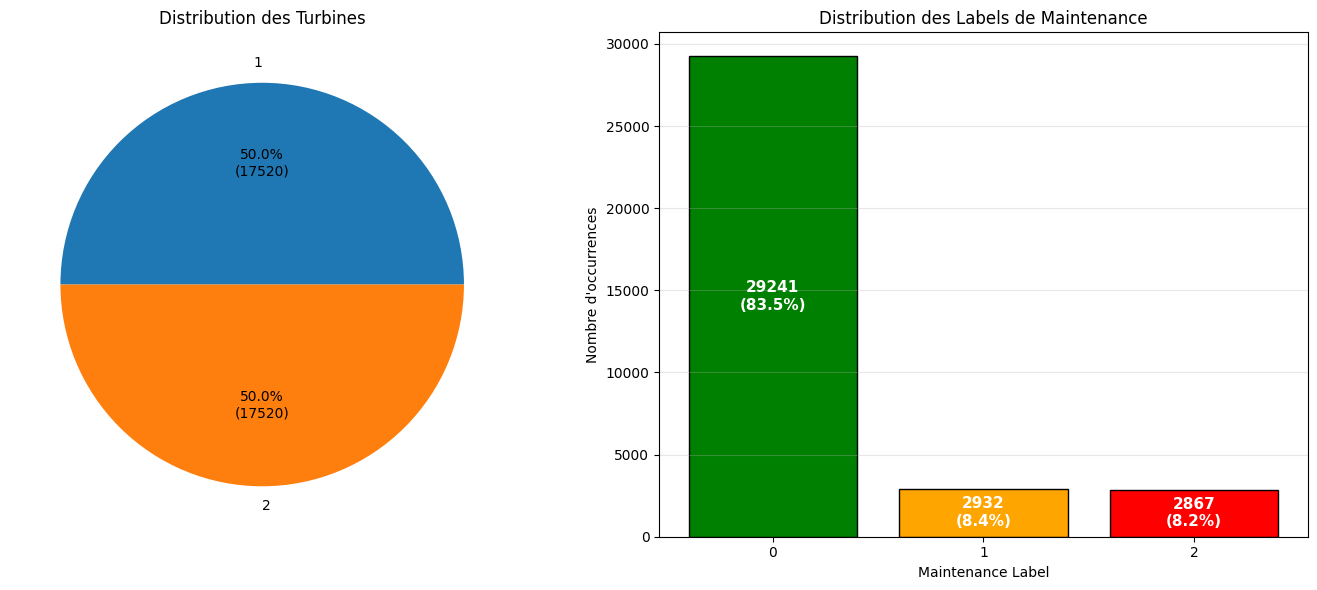

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PIE CHART - Turbine IDs
turbine_counts = dataset['Turbine_ID'].value_counts().sort_index()
axes[0].pie(turbine_counts.values, 
            labels=turbine_counts.index, 
            autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*turbine_counts.sum())})')
axes[0].set_title("Distribution des Turbines")

# BAR CHART - Maintenance Labels
maintenance_counts = dataset['Maintenance_Label'].value_counts()
total = maintenance_counts.sum()
colors = {0: 'green', 1: 'orange', 2: 'red'}
bar_colors = [colors[label] for label in maintenance_counts.index]

container = axes[1].bar(maintenance_counts.index, maintenance_counts.values, color=bar_colors, edgecolor='black')

# Ajouter count + pourcentage DANS les barres
for label, count in zip(maintenance_counts.index, maintenance_counts.values):
    percentage = count / total * 100
    axes[1].text(label, count/2, f'{count}\n({percentage:.1f}%)', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

axes[1].set_title("Distribution des Labels de Maintenance")
axes[1].set_xlabel("Maintenance Label")
axes[1].set_ylabel("Nombre d'occurrences")
axes[1].set_xticks([0, 1, 2]) 
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

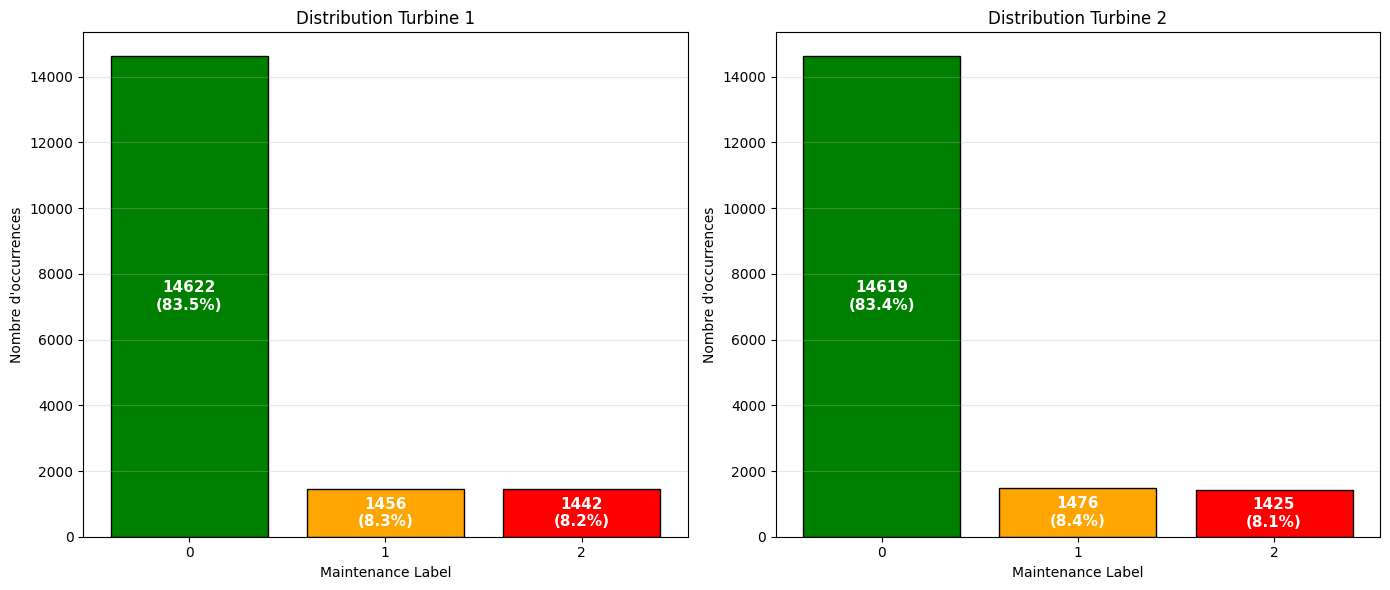

In [5]:
def plot_turbine(ax, turbine_id):
    counts = dataset[dataset['Turbine_ID'] == turbine_id]['Maintenance_Label'].value_counts().sort_index()
    total = counts.sum()
    
    colors = {0: 'green', 1: 'orange', 2: 'red'}
    bar_colors = [colors[label] for label in counts.index]
    
    container = ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='black')
    
    # Ajouter count + pourcentage DANS les barres
    for i, (label, count) in enumerate(zip(counts.index, counts.values)):
        percentage = count / total * 100
        ax.text(label, count/2, f'{count}\n({percentage:.1f}%)', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    
    ax.set_title(f"Distribution Turbine {turbine_id}")
    ax.set_xlabel("Maintenance Label")
    ax.set_ylabel("Nombre d'occurrences")
    ax.set_xticks([0, 1, 2])
    ax.grid(axis='y', alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_turbine(axes[0], 1)
plot_turbine(axes[1], 2)

plt.tight_layout()
plt.show()

### Séparation par turbine

Le dataset contient deux turbines (ID 1 et 2). On les sépare pour travailler indépendamment sur chacune. La suite du notebook se concentre sur la **Turbine 1**.

In [6]:
Turbine1 = dataset[dataset['Turbine_ID'] == 1]
Turbine2 = dataset[dataset['Turbine_ID'] == 2]

### Matrice de corrélation

On visualise les corrélations entre variables numériques pour chaque turbine. Des corrélations fortes entre features peuvent indiquer de la redondance d'information.

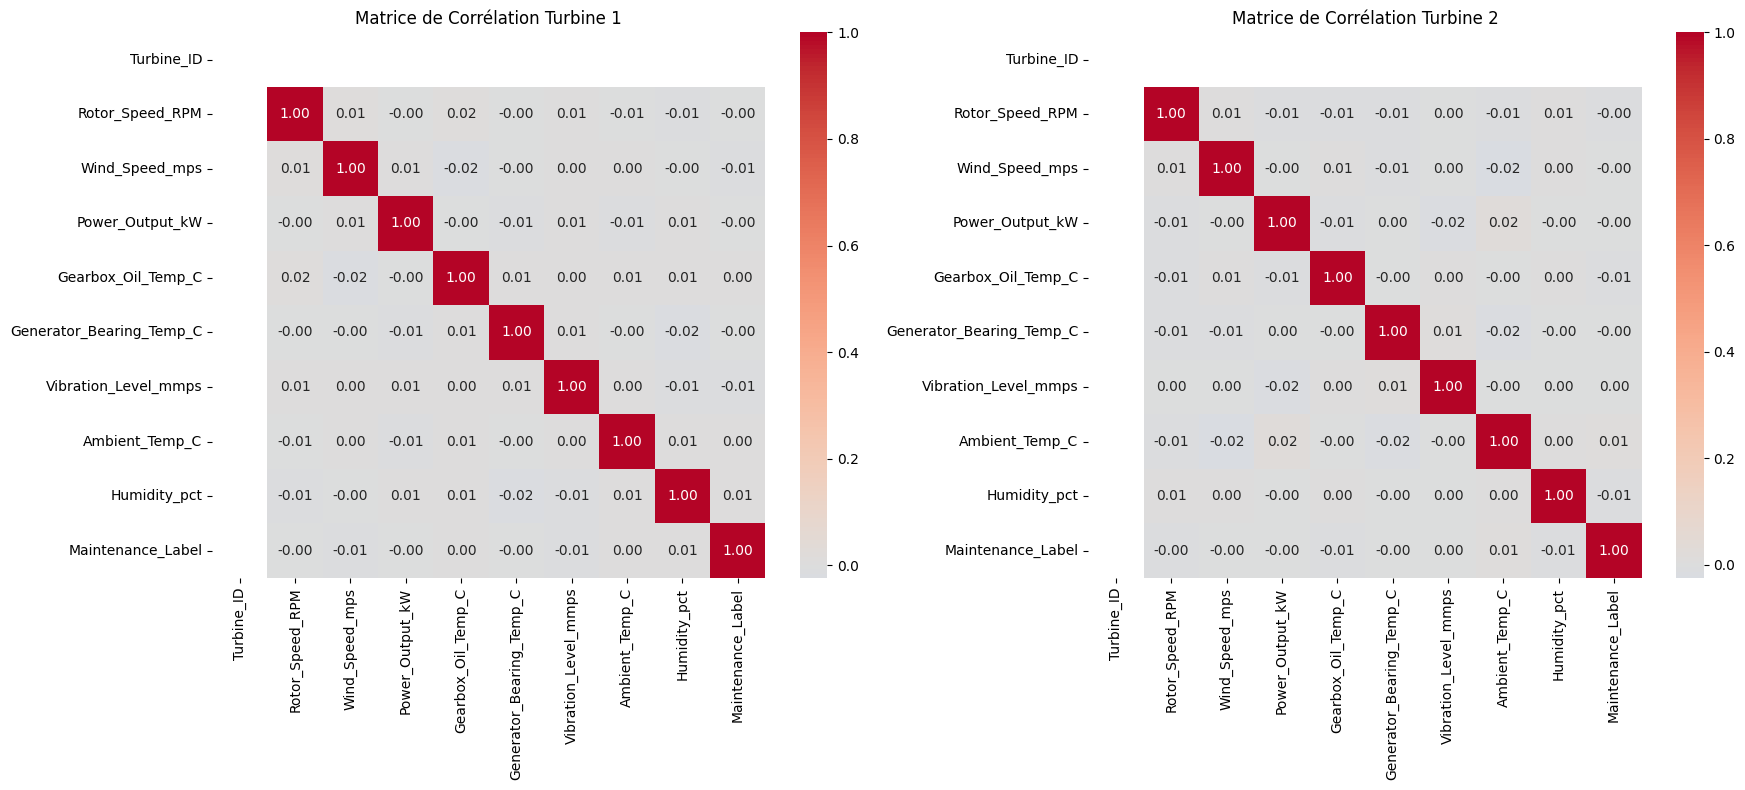

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Turbine 1
turbine1 = dataset[dataset['Turbine_ID'] == 1]
correlation_matrix1 = turbine1.corr()
sns.heatmap(correlation_matrix1, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[0])
axes[0].set_title('Matrice de Corrélation Turbine 1')

# Turbine 2
turbine2 = dataset[dataset['Turbine_ID'] == 2]
correlation_matrix2 = turbine2.corr()
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Matrice de Corrélation Turbine 2')

plt.tight_layout()
plt.show()

In [8]:
# Aperçu du sous-dataset Turbine 1 avant nettoyage
Turbine1.head(10)

,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
0,1,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0
1,1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0
2,1,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0
3,1,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0
4,1,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1
5,1,14.156580,7.486675,1495.646320,63.623495,67.184666,1.840874,14.652922,66.777674,0
6,1,15.211587,8.597045,1410.366482,64.440061,82.344706,1.775220,14.750027,77.265165,0
7,1,14.927990,9.003533,1536.163603,61.774401,76.806978,2.307607,9.820870,75.646437,0
8,1,14.601362,7.939136,1358.124954,70.212458,79.517662,2.003800,7.327918,45.049461,0
9,1,16.622920,8.823733,1529.305925,69.483152,71.948390,1.936767,2.587879,57.711525,0


### Comportement des capteurs selon le label de maintenance

On regarde comment les valeurs des 6 capteurs physiques varient selon le besoin de maintenance. C'est une des questions centrales : est-ce que les capteurs « voient » la panne avant qu'elle arrive ?

/var/folders/y2/s_g586dx0hzbn9jfxpnwbpb00000gn/T/ipykernel_2006/3754553293.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_label, patch_artist=True,
/var/folders/y2/s_g586dx0hzbn9jfxpnwbpb00000gn/T/ipykernel_2006/3754553293.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_label, patch_artist=True,
/var/folders/y2/s_g586dx0hzbn9jfxpnwbpb00000gn/T/ipykernel_2006/3754553293.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_by_label, patch_artist=True,
/var/folders/y2/s_g586dx0hzbn9jfxpnwbpb00000gn/T/ipykernel_2006/3754553293.p

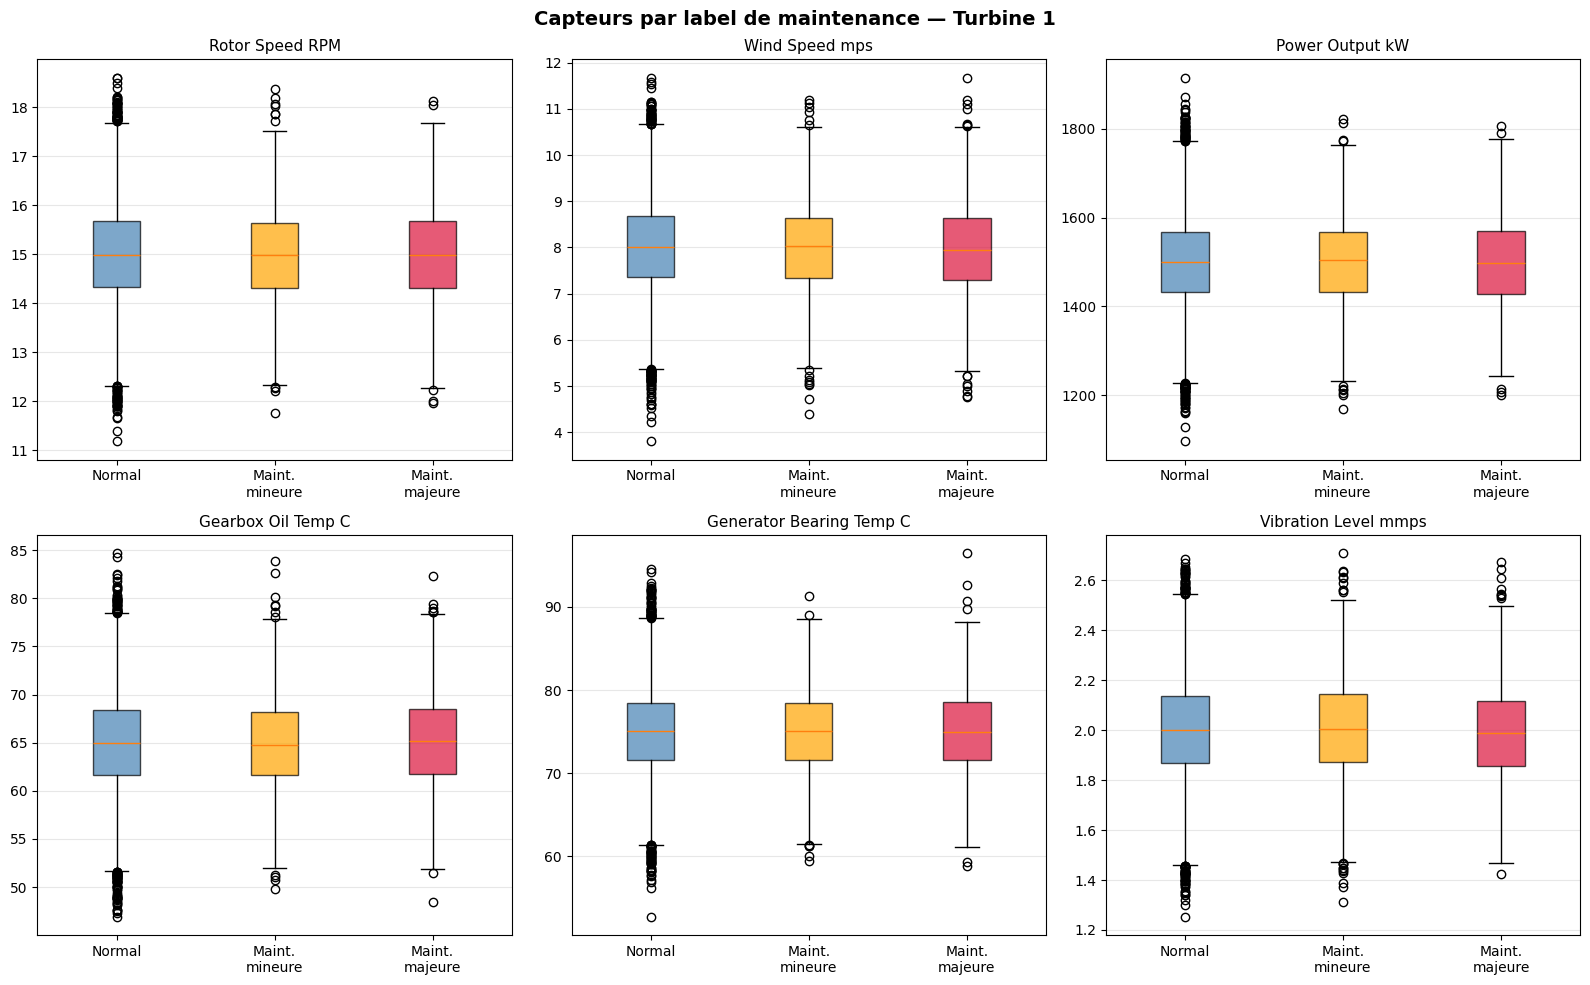

In [9]:
t1 = dataset[dataset['Turbine_ID'] == 1].copy()

sensor_cols = [
    'Rotor_Speed_RPM', 'Wind_Speed_mps', 'Power_Output_kW',
    'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C', 'Vibration_Level_mmps'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
label_colors = {0: 'steelblue', 1: 'orange', 2: 'crimson'}

for i, col in enumerate(sensor_cols):
    data_by_label = [
        t1[t1['Maintenance_Label'] == label][col].dropna().values
        for label in [0, 1, 2]
    ]
    bp = axes[i].boxplot(data_by_label, patch_artist=True,
                         labels=['Normal', 'Maint.\nmineure', 'Maint.\nmajeure'])
    for patch, label in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(label_colors[label])
        patch.set_alpha(0.7)
    axes[i].set_title(col.replace('_', ' '), fontsize=11)
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Capteurs par label de maintenance — Turbine 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Distribution des capteurs les plus liés aux pannes

Les courbes de densité permettent de voir si les distributions se séparent selon le label. On se concentre sur `Vibration_Level_mmps`, `Gearbox_Oil_Temp_C` et `Generator_Bearing_Temp_C` qui sont physiquement les plus liés à l'usure mécanique.

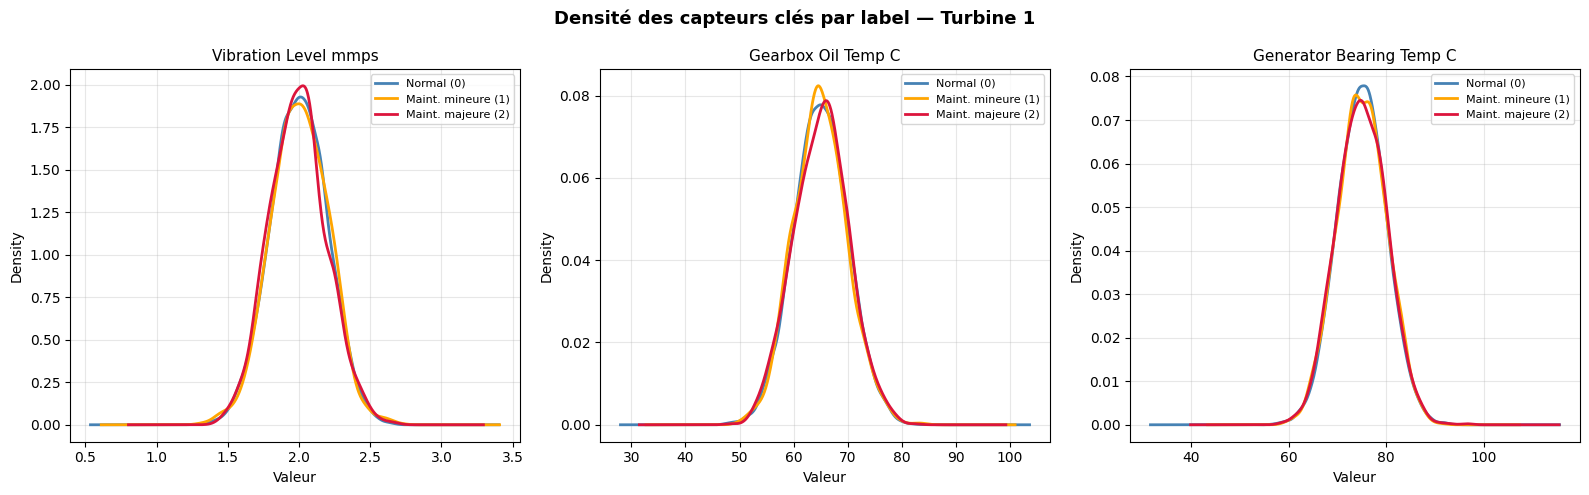

In [10]:
focus_cols = ['Vibration_Level_mmps', 'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C']
colors     = {0: 'steelblue', 1: 'orange', 2: 'crimson'}
labels_txt = {0: 'Normal (0)', 1: 'Maint. mineure (1)', 2: 'Maint. majeure (2)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, focus_cols):
    for label in [0, 1, 2]:
        subset = t1[t1['Maintenance_Label'] == label][col].dropna()
        subset.plot.kde(ax=ax, color=colors[label],
                        label=labels_txt[label], linewidth=2)
    ax.set_title(col.replace('_', ' '), fontsize=11)
    ax.set_xlabel('Valeur')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Densité des capteurs clés par label — Turbine 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Conclusion de l'EDA

Quelques points à retenir avant de passer à la modélisation :

- Le dataset est bien équilibré entre les deux turbines (~50/50), ce qui est rassurant.
- En revanche, les labels de maintenance sont très déséquilibrés : la classe 0 (pas de maintenance) est largement majoritaire, les classes 1 et 2 sont rares. Il faudra en tenir compte dans le choix du modèle (option `class_weight='balanced'` ou métrique F1 macro).
- Les corrélations entre variables sont modérées — pas de feature à supprimer d'emblée pour redondance évidente, mais `Ambient_Temp_C` et `Humidity_pct` semblent peu liées aux autres capteurs physiques.
- Les deux turbines ont des distributions similaires, ce qui justifie de les traiter de façon identique.

On garde `Turbine1` pour la suite et on supprime les colonnes peu informatives avant l'entraînement.